In [10]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
import numpy as np

df_21 = pd.read_csv('../../Projektdatensaetze/2021/ergebnissefahrradzaehlungen2021_REFACTORED.csv',
                 sep=';', skiprows=2)
df_21.drop(index=df_21.index[-1],axis=0,inplace=True)
df_21['time'] = pd.to_datetime(df_21['time'], dayfirst=True, format='%d. %m. %Y %H:%M')
df_21 = df_21.apply(lambda crossings: crossings.fillna(crossings.mean()) if crossings.dtype in ['float64', 'int64'] else crossings)
df_21['days'] = df_21['time'].dt.date

df_21 = pd.DataFrame(df_21.groupby('days')['5.07 BN - Estermannufer'].sum())

for i in df_21['5.07 BN - Estermannufer']:
        print(i)

df_2022 = pd.read_csv('../../Projektdatensaetze/2022/FahrradBonn2022_COPY.csv',
                 sep=';', skiprows=1)
df_2022.drop(index=df_2022.index[-1],axis=0,inplace=True)
df_2022['time'] = pd.to_datetime(df_2022['time'], format='%Y-%m-%d %H:%M')

df_2022['days'] = df_2022['time'].dt.date

df_day_bonn = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Bonn'].sum()
df_day_koeln = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Köln'].sum()

df_22_sum = df_day_bonn + df_day_koeln

df_2023 = pd.read_csv('../../Projektdatensaetze/2023/Fahrradzaehlstellen2023_stuendlich_RENAMED.csv',
                 sep=';')

df_2023['time'] = pd.to_datetime(df_2023['time'], format='%d.%m.%Y %H:%M')
df_2023['time'] = df_2023['time'].dt.strftime('%Y-%m-%d %H:%M')
df_2023['time'] = pd.to_datetime(df_2023['time'], format='%Y-%m-%d %H:%M')
#print(type(df_2023['time']))
#display(df_2023)
df_2023['days'] = df_2023['time'].dt.date


df_day_23 = df_2023.groupby('days')['5.07 BN - Estermannufer'].sum()
#display(df_day_23)


221.0
407.0
320.0
235.0
270.0
243.0
155.0
183.0
218.0
327.0
269.0
119.0
336.0
286.0
265.0
310.0
61.0
338.0
164.0
429.0
336.0
380.0
702.0
114.0
157.0
206.0
160.0
73.0
137.0
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
698.2699646643109
145.47290930506477
22.0
47.0
132.0
194.0
54.0
293.0
410.0
266.0
556.0
1393.0
1982.0
656.0
1038.0
1359.0
1216.0
338.0
767.0
1371.0
744.0
937.0
1037.0
148.0
421.0
734.0
799.0
382.0
202.0
484.0
236.0
287.0
126.0
296.0
197.0
299.0
292.0
355.0
503.0
756.0
385.0
354.0
571.0
1104.0
664.0
882.0
332.0
1239.094581861013
1589.0
1946.0
2025.0
1321.0
815.0
933.0
518.0
111.0
151.0
119.0
505.0
999.0
244.0
73.0
388.0
459.0
483.0
506.0
558.0
1076.0
800.0
430.0
1222.0
697.0
773.0
943.0
1622.0
1788.0
1010.0
1116.0
1296.0
358.0
574.0
1417.0
838.0
667.0
251.0
291.0
396.0
423.0
842.0
2541.0
680.0
438.0
778.0
2253.0
818.0
480.0
632.0
403.0
319.0

In [14]:
df_ = pd.DataFrame()
df_['5.07 BN - Estermannufer']= df_day_bonn + df_day_koeln
df = pd.concat([df_21, df_, df_day_23])

df = pd.DataFrame(df)
df = df.asfreq('d')
display(df)

#df['5.07 BN - Estermannufer'].dtype


,5.07 BN - Estermannufer
days,
2021-01-01,221.0
2021-01-02,407.0
2021-01-03,320.0
2021-01-04,235.0
2021-01-05,270.0
...,...
2023-12-27,0.0
2023-12-28,0.0
2023-12-29,3.0


In [15]:
#prüfe auf Stationarität
from statsmodels.tsa.stattools import adfuller
result = adfuller(df)
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -2.1214
p-value = 0.2360


Datenaufbereitung

1. Vergleiche Autokorrelation vs. partielle Autokorrelation
2. teile in Trainings- und Testdaten ein
3. Stelle Stationarität her

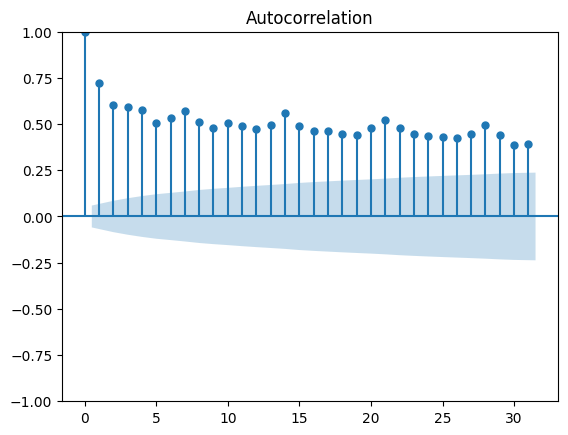

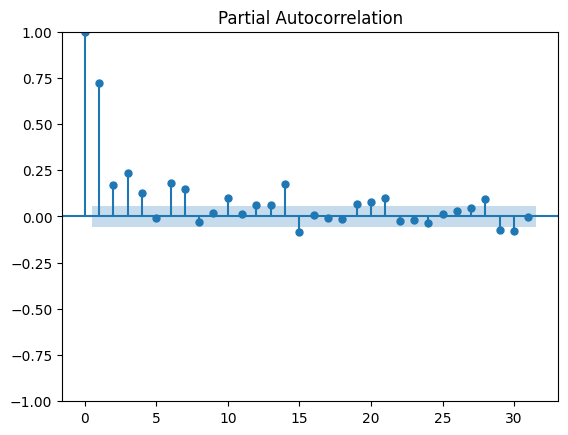

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df)
plot_pacf(df)
plt.show()

In [17]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]
display(df_train)


,5.07 BN - Estermannufer
days,
2021-01-01,221.0
2021-01-02,407.0
2021-01-03,320.0
2021-01-04,235.0
2021-01-05,270.0
...,...
2023-09-09,1385.0
2023-09-10,1861.0
2023-09-11,1180.0


In [19]:
df_train.loc[:,'differences'] = df_train['5.07 BN - Estermannufer'].diff().fillna(0)
result = adfuller(df_train['differences'])
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -11.7735
P-value = 0.0000


In [22]:
#display(df_train)

                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(1, 1, 0)   Log Likelihood               -7185.684
Date:                     Sun, 15 Dec 2024   AIC                          14375.368
Time:                             17:41:39   BIC                          14385.153
Sample:                         01-01-2021   HQIC                         14379.090
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2880      0.019    -14.945      0.000      -0.326      -0.250
sigma2      1.271e+05   3218.369     39.503      0.000    1.21e+05    1.33e+05
Ljung-Box (L

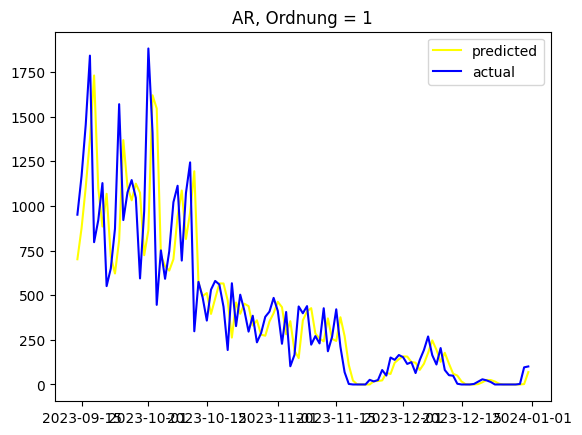

mean absolute error (mae): ARIMA: 147.7409, simple: 160.7339
mean squared error (mse): ARIMA: 66711.3266, simple: 70775.1743
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(2, 1, 0)   Log Likelihood               -7140.422
Date:                     Sun, 15 Dec 2024   AIC                          14286.845
Time:                             17:41:45   BIC                          14301.523
Sample:                         01-01-2021   HQIC                         14292.427
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3736      0.020    -19.136  

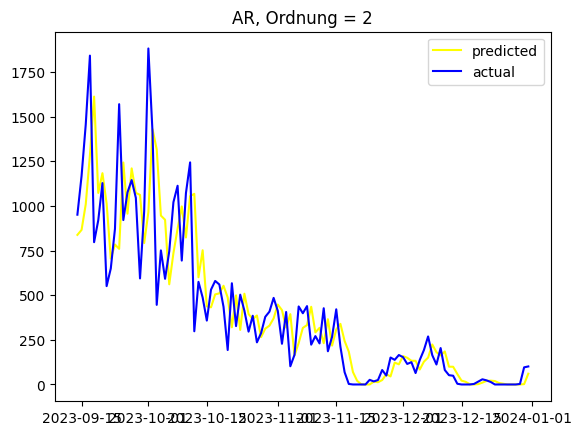

mean absolute error (mae): ARIMA: 143.2061, simple: 160.7339
mean squared error (mse): ARIMA: 56485.6931, simple: 70775.1743
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(3, 1, 0)   Log Likelihood               -7124.934
Date:                     Sun, 15 Dec 2024   AIC                          14257.868
Time:                             17:41:47   BIC                          14277.439
Sample:                         01-01-2021   HQIC                         14265.312
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4261      0.020    -21.225  

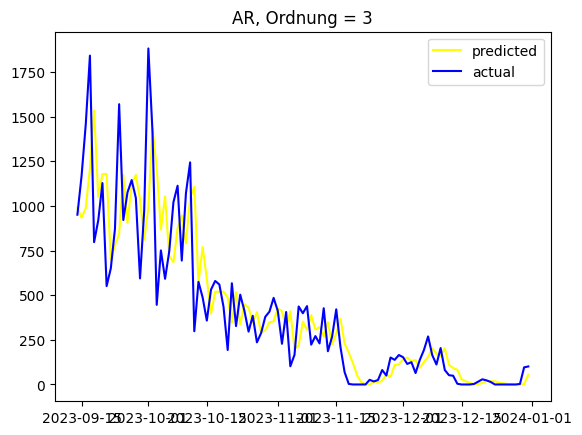

mean absolute error (mae): ARIMA: 143.1707, simple: 160.7339
mean squared error (mse): ARIMA: 55684.0418, simple: 70775.1743
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(4, 1, 0)   Log Likelihood               -7124.609
Date:                     Sun, 15 Dec 2024   AIC                          14259.218
Time:                             17:41:48   BIC                          14283.681
Sample:                         01-01-2021   HQIC                         14268.522
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4307      0.020    -21.367  

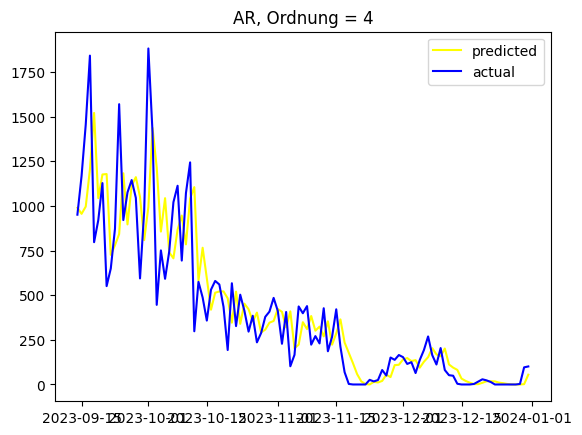

mean absolute error (mae): ARIMA: 142.5309, simple: 160.7339
mean squared error (mse): ARIMA: 55233.2518, simple: 70775.1743
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(5, 1, 0)   Log Likelihood               -7102.708
Date:                     Sun, 15 Dec 2024   AIC                          14217.415
Time:                             17:41:49   BIC                          14246.771
Sample:                         01-01-2021   HQIC                         14228.581
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4361      0.020    -21.584  

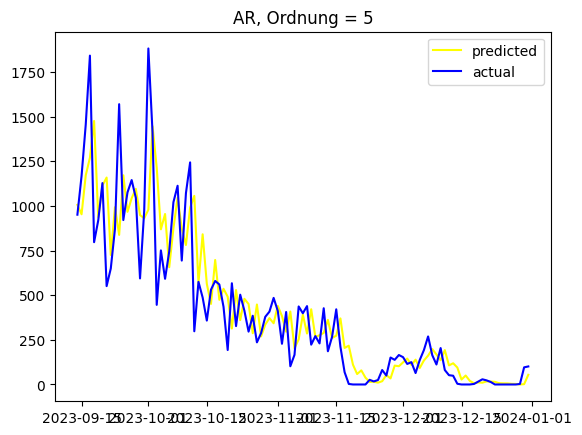

mean absolute error (mae): ARIMA: 136.1594, simple: 160.7339
mean squared error (mse): ARIMA: 49979.2322, simple: 70775.1743


In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 6):
    p, d, q = i, 1, 0
    #arima = SARIMAX(df_train['differences'], order=(p, d, q), freq='D')
    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)
    
    # Vorhersage
    predicted = result_new.predict(start='2023-09-14')
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    
    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    start_date = '2023-09-14'
    end_date='2023-12-31'
    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    #plt.plot(df_r['5.07 BN - Estermannufer'].iloc[656: 730], color='yellow', label='predicted')
    plt.plot(df_r.loc['2023-09-14':'2023-12-31', '5.07 BN - Estermannufer'], 
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, '5.07 BN - Estermannufer'], color='blue', label='actual')
    plt.legend()
    plt.show()
    
    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()
    
    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    
    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))

                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(0, 1, 1)   Log Likelihood               -4613.494
Date:                     Tue, 10 Dec 2024   AIC                           9230.989
Time:                             11:26:28   BIC                           9239.961
Sample:                         01-01-2022   HQIC                          9234.467
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8111      0.016    -49.747      0.000      -0.843      -0.779
sigma2      7.507e+04   1921.816     39.064      0.000    7.13e+04    7.88e+04
Ljung-Box (L

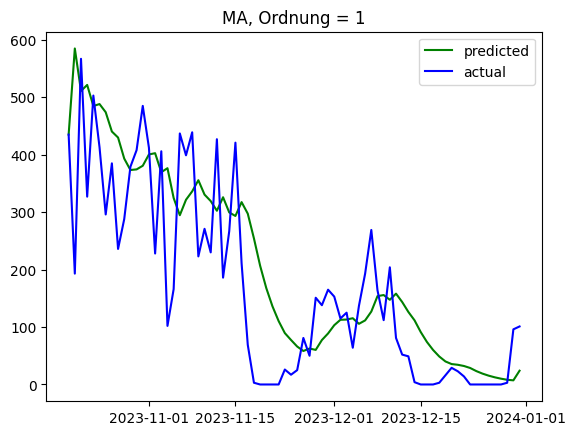

mean absolute error (mae): ARIMA: 84.6133, simple: 75.1507
mean squared error (mse): ARIMA: 12461.8974, simple: 12769.9726


In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 2):
    p, d, q = 0, 1, i
    #arima = SARIMAX(df_train['differences'], order=(p, d, q), freq='D')
    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)
    
    # Vorhersage
    predicted = result_new.predict(start='2023-10-20')
    tmp = pd.DataFrame(predicted)
    #tmp['differences'] = tmp['predicted_mean']
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    #display(tmp)
    #display(df_train)
    
    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)
    

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    
    # Plotten
    plt.title('MA, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r['5.07 BN - Estermannufer'].iloc[656: 730], color='green', label='predicted')
    plt.plot(df['5.07 BN - Estermannufer'].iloc[656: 730], color='blue', label='actual')
    plt.legend()
    plt.show()
    
    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()
    
    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    
    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))